# Distribution comparison: scvi-tools NB vs Pyro GammaPoisson

This notebook compares two implementations of the Negative Binomial distribution:

1. **scvi-tools `NegativeBinomial(mu, theta)`** — custom implementation using `log_nb_positive`
2. **Pyro `GammaPoisson(concentration, rate)`** — standard Pyro distribution

Both model the same distribution: a Poisson whose rate is Gamma-distributed.
The NB variance is $\text{Var}(x) = \mu + \mu^2/\theta$, where:
- $\mu$ is the mean
- $\theta$ is the inverse dispersion (= GammaPoisson concentration)
- Large $\theta$ → Poisson-like (low overdispersion)
- Small $\theta$ → high overdispersion

We also compare two prior directions for dispersion regularisation:
- **Current (regularizedvi default)**: Exp prior on $\sqrt{\theta}$ → pushes $\theta$ small
- **Flipped (cell2location direction)**: Exp prior on $1/\sqrt{\theta}$ → pushes $\theta$ large (toward Poisson)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

## 1. Numerical verification

Grid comparison of `log_prob` values with **fixed mean** $\mu$ and varying $\theta$ (concentration).

In [2]:
from regularizedvi.utils import compare_nb_gammapoisson, plot_nb_vs_gammapoisson

# Compare with fixed mu=5, varying theta from 0.01 to 1000
results = compare_nb_gammapoisson(x_range=(0, 50), mu=5.0, theta_range=(0.01, 1000), n_theta=80)

print(f"Max absolute difference: {np.abs(results['diff']).max():.2e}")
print(f"Mean absolute difference: {np.abs(results['diff']).mean():.2e}")
print("\nConclusion: Differences are floating-point only (< 1e-6)")

Max absolute difference: 9.07e-04
Mean absolute difference: 2.93e-05

Conclusion: Differences are floating-point only (< 1e-6)


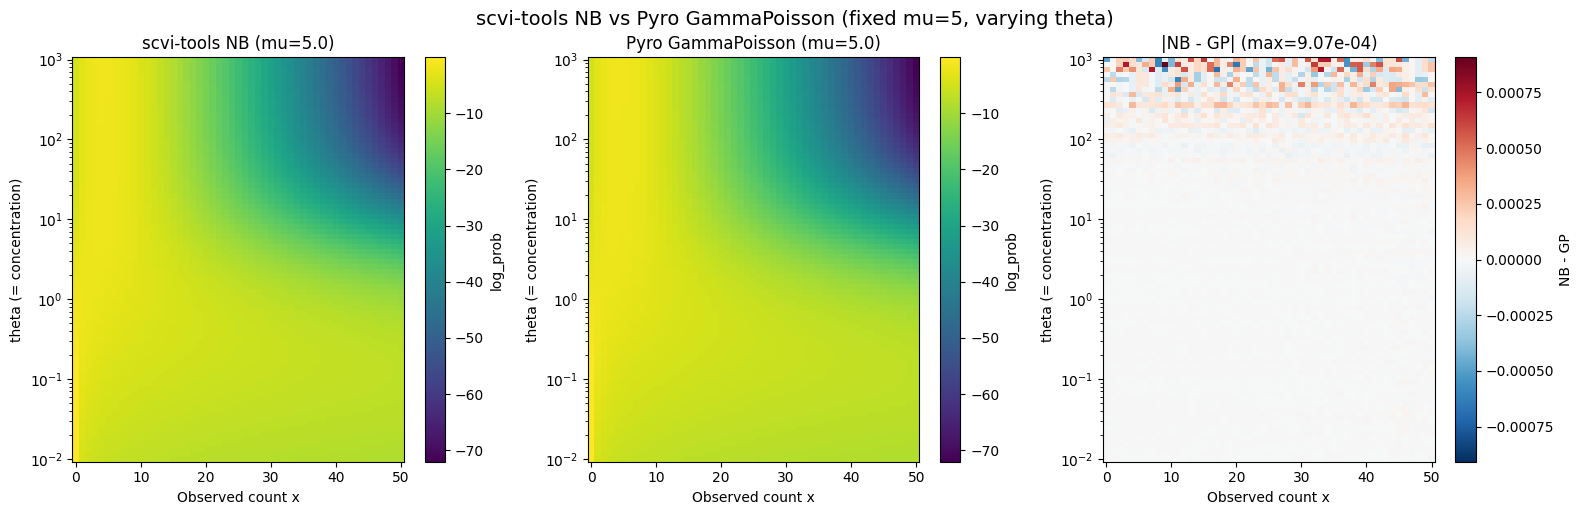

In [3]:
fig = plot_nb_vs_gammapoisson(results)
plt.suptitle("scvi-tools NB vs Pyro GammaPoisson (fixed mu=5, varying theta)", y=1.02, fontsize=14)
plt.show()

In [4]:
# Repeat with different mu values to confirm equivalence holds
for mu_val in [1.0, 10.0, 50.0]:
    res = compare_nb_gammapoisson(x_range=(0, 100), mu=mu_val, theta_range=(0.01, 1000), n_theta=50)
    max_diff = np.abs(res["diff"]).max()
    print(f"mu={mu_val:5.1f}: max |NB - GP| = {max_diff:.2e}")

mu=  1.0: max |NB - GP| = 1.16e-03
mu= 10.0: max |NB - GP| = 1.16e-03
mu= 50.0: max |NB - GP| = 7.93e-04


## 2. What does theta control?

NB variance: $\text{Var}(x) = \mu + \mu^2/\theta$

- $\theta \to \infty$: $\text{Var}(x) \to \mu$ (Poisson limit)
- $\theta \to 0$: $\text{Var}(x) \to \infty$ (extreme overdispersion)

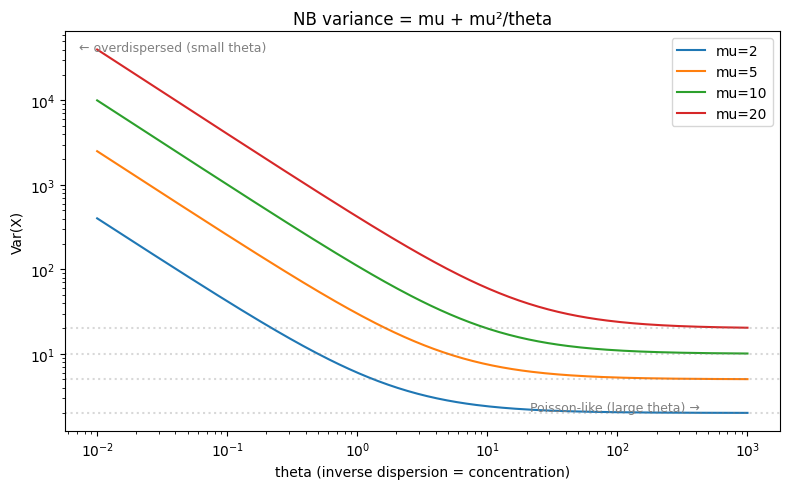

In [5]:
from regularizedvi.utils import nb_variance

theta = np.logspace(-2, 3, 200)

fig, ax = plt.subplots(figsize=(8, 5))
for mu_val in [2, 5, 10, 20]:
    var = nb_variance(mu_val, theta)
    ax.plot(theta, var, label=f"mu={mu_val}")
    ax.axhline(mu_val, color="gray", linestyle=":", alpha=0.3)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("theta (inverse dispersion = concentration)")
ax.set_ylabel("Var(X)")
ax.set_title("NB variance = mu + mu²/theta")
ax.legend()
ax.annotate("← overdispersed (small theta)", xy=(0.02, 0.95), xycoords="axes fraction", fontsize=9, color="gray")
ax.annotate("Poisson-like (large theta) →", xy=(0.65, 0.05), xycoords="axes fraction", fontsize=9, color="gray")
plt.tight_layout()
plt.show()

## 3. The dispersion prior — two directions

The Exponential distribution always pushes its argument toward zero. The difference is **which quantity** the prior is placed on:

### Direction 1 (current regularizedvi default): $\sqrt{\theta} \sim \text{Exp}(\lambda)$

- Pushes $\sqrt{\theta} \to 0$ → $\theta$ **small** → away from Poisson
- Prior expectation: $\mathbb{E}[\sqrt{\theta}] = 1/\lambda = 1/3$, so $\theta \approx 1/9$
- Counteracts gradient-based training which tends to push $\theta$ large

### Direction 2 (cell2location direction): $1/\sqrt{\theta} \sim \text{Exp}(\lambda)$

- Pushes $1/\sqrt{\theta} \to 0$ → $\theta$ **large** → toward Poisson
- Prior expectation: $\mathbb{E}[1/\sqrt{\theta}] = 1/\lambda = 1/3$, so $\theta \approx 9$
- The approach used in cell2location/cell2fate (Bayesian inference with Pyro)

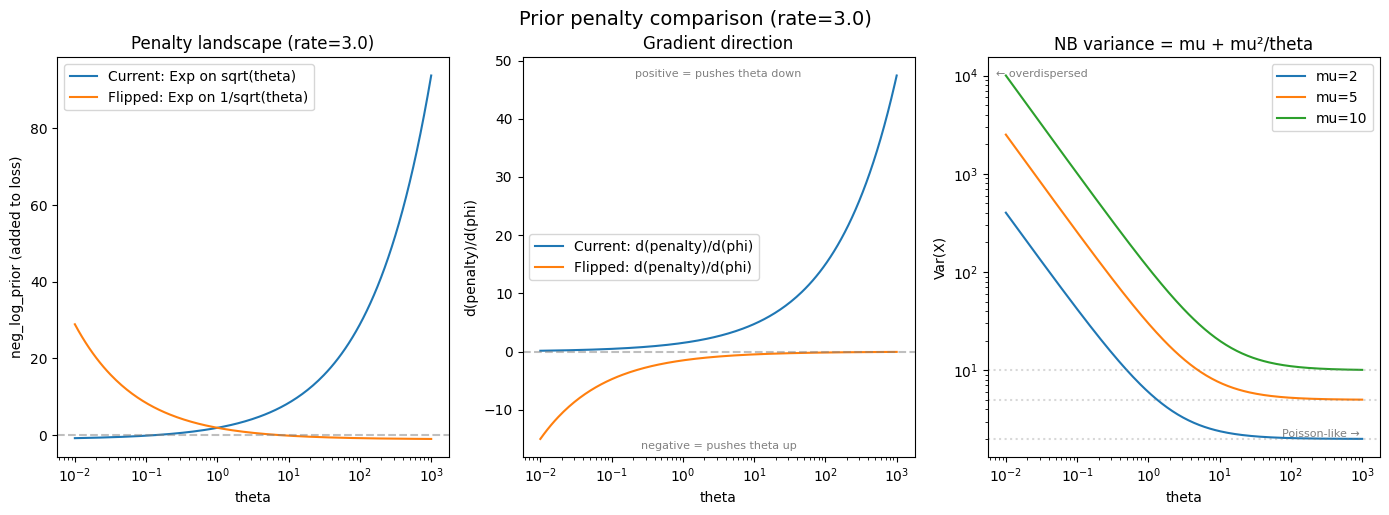

In [6]:
from regularizedvi.utils import compare_prior_directions, plot_prior_comparison

prior_results = compare_prior_directions(theta_range=(0.01, 1000), rate=3.0)

fig = plot_prior_comparison(prior_results)
plt.suptitle("Prior penalty comparison (rate=3.0)", y=1.02, fontsize=14)
plt.show()

## 4. Gradient verification

Verify the gradient direction with autograd. The model parameterises $\theta = \exp(\phi)$ where $\phi$ is the unconstrained parameter (`self.px_r`).

In [7]:
from torch.distributions import Exponential

rate = 3.0

print("Direction 1 (current): Exp prior on sqrt(theta)")
print(f"{'phi':>8} {'theta':>10} {'neg_logp':>12} {'d/d(phi)':>12}  interpretation")
print("-" * 65)
for phi_val in [-3.0, -1.0, 0.0, 1.0, 3.0, 6.0]:
    phi = torch.tensor(phi_val, requires_grad=True)
    theta = torch.exp(phi)
    sqrt_theta = theta.pow(0.5)
    neg_logp = -Exponential(torch.tensor(rate)).log_prob(sqrt_theta)
    neg_logp.backward()
    direction = "→ push phi DOWN (theta DOWN)" if phi.grad.item() > 0 else "→ push phi UP (theta UP)"
    print(f"{phi_val:+8.1f} {theta.item():10.4f} {neg_logp.item():12.4f} {phi.grad.item():+12.6f}  {direction}")

print("\nAll gradients POSITIVE → optimizer pushes phi DOWN → theta DOWN (away from Poisson)")
print()

print("Direction 2 (flipped): Exp prior on 1/sqrt(theta)")
print(f"{'phi':>8} {'theta':>10} {'neg_logp':>12} {'d/d(phi)':>12}  interpretation")
print("-" * 65)
for phi_val in [-3.0, -1.0, 0.0, 1.0, 3.0, 6.0]:
    phi = torch.tensor(phi_val, requires_grad=True)
    theta = torch.exp(phi)
    inv_sqrt_theta = theta.pow(-0.5)  # = 1/sqrt(theta) = exp(-phi/2)
    neg_logp = -Exponential(torch.tensor(rate)).log_prob(inv_sqrt_theta)
    neg_logp.backward()
    direction = "→ push phi DOWN (theta DOWN)" if phi.grad.item() > 0 else "→ push phi UP (theta UP)"
    print(f"{phi_val:+8.1f} {theta.item():10.4f} {neg_logp.item():12.4f} {phi.grad.item():+12.6f}  {direction}")

print("\nAll gradients NEGATIVE → optimizer pushes phi UP → theta UP (toward Poisson)")

Direction 1 (current): Exp prior on sqrt(theta)
     phi      theta     neg_logp     d/d(phi)  interpretation
-----------------------------------------------------------------
    -3.0     0.0498      -0.4292    +0.334695  → push phi DOWN (theta DOWN)
    -1.0     0.3679       0.7210    +0.909796  → push phi DOWN (theta DOWN)
    +0.0     1.0000       1.9014    +1.500000  → push phi DOWN (theta DOWN)
    +1.0     2.7183       3.8476    +2.473082  → push phi DOWN (theta DOWN)
    +3.0    20.0855      12.3465    +6.722534  → push phi DOWN (theta DOWN)
    +6.0   403.4288      59.1580   +30.128304  → push phi DOWN (theta DOWN)

All gradients POSITIVE → optimizer pushes phi DOWN → theta DOWN (away from Poisson)

Direction 2 (flipped): Exp prior on 1/sqrt(theta)
     phi      theta     neg_logp     d/d(phi)  interpretation
-----------------------------------------------------------------
    -3.0     0.0498      12.3465    -6.722533  → push phi UP (theta UP)
    -1.0     0.3679       3.8476

## 5. Prior expected values

| | Direction 1 (current) | Direction 2 (flipped) |
|---|---|---|
| Prior on | $\sqrt{\theta} \sim \text{Exp}(3)$ | $1/\sqrt{\theta} \sim \text{Exp}(3)$ |
| $\mathbb{E}[\text{argument}]$ | $1/3$ | $1/3$ |
| Expected $\theta$ | $\approx 1/9 \approx 0.11$ | $\approx 9$ |
| Expected overdispersion $1/\theta$ | $\approx 9$ | $\approx 1/9$ |
| NB Var at $\mu=5$ | $5 + 225 = 230$ | $5 + 25/9 \approx 7.8$ |
| Direction | Away from Poisson | Toward Poisson |

In [8]:
mu = 5.0

# Direction 1
theta_d1 = 1 / 9  # E[sqrt(theta)] = 1/3 → E[theta] ≈ 1/9
var_d1 = mu + mu**2 / theta_d1
print(f"Direction 1 (current): E[theta] ≈ {theta_d1:.4f}")
print(f"  NB Var at mu={mu}: {var_d1:.1f}  (highly overdispersed)")
print()

# Direction 2
theta_d2 = 9.0  # E[1/sqrt(theta)] = 1/3 → E[theta] ≈ 9
var_d2 = mu + mu**2 / theta_d2
print(f"Direction 2 (flipped): E[theta] ≈ {theta_d2:.4f}")
print(f"  NB Var at mu={mu}: {var_d2:.1f}  (moderate overdispersion)")
print()

# Poisson
print(f"Poisson (theta → ∞): Var = {mu:.1f}")

Direction 1 (current): E[theta] ≈ 0.1111
  NB Var at mu=5.0: 230.0  (highly overdispersed)

Direction 2 (flipped): E[theta] ≈ 9.0000
  NB Var at mu=5.0: 7.8  (moderate overdispersion)

Poisson (theta → ∞): Var = 5.0


## 6. Using both modes in regularizedvi

regularizedvi supports both prior directions via the `likelihood_distribution` parameter:

- `likelihood_distribution="nb"` (default): scvi-tools NB + Exp prior on $\sqrt{\theta}$
- `likelihood_distribution="gamma_poisson"`: Pyro GammaPoisson + Exp prior on $1/\sqrt{\theta}$

The distributions are mathematically identical; only the prior direction differs.

In [9]:
# Example usage (not training on real data here):
#
# import regularizedvi
#
# # Default: NB + Exp on sqrt(theta)
# model_nb = regularizedvi.AmbientRegularizedSCVI(
#     adata,
#     likelihood_distribution="nb",  # default
# )
#
# # Alternative: GammaPoisson + Exp on 1/sqrt(theta) (cell2location direction)
# model_gp = regularizedvi.AmbientRegularizedSCVI(
#     adata,
#     likelihood_distribution="gamma_poisson",
# )

print("Both modes are available for empirical comparison on real data.")
print("The tutorial notebook shows how to train and compare both.")

Both modes are available for empirical comparison on real data.
The tutorial notebook shows how to train and compare both.
